# Tanager Mangrove Mapping - 03 Transferability

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent Mapping Using Adaptive Spectral Thresholds |
| **Date**        | June 2026 |

---

**Scope:** Apply pipeline trained on Sangatta to Gujarat, El Salvador, Belize, Australia. Per-scene adaptive threshold recalibration — no retraining. Accuracy evaluation against GMW v3.

## 0. Environment Setup

In [1]:
!pip install scikit-learn geopandas rasterio matplotlib joblib xgboost



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [3]:
import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# Project root
# ============================================================
# Google Colab (Google Drive mounted)
#ROOT        = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
ROOT = Path('..').resolve()

DATA_RAW    = ROOT / 'data' / 'raw'
DATA_PROC   = ROOT / 'data' / 'processed'
DATA_GMW    = ROOT / 'data' / 'gmw_v3'
OUT_MODELS  = ROOT / 'outputs' / 'models'
OUT_RESULTS = ROOT / 'outputs' / 'results'
OUT_FIGURES = ROOT / 'outputs' / 'figures'

for d in (OUT_MODELS, OUT_RESULTS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

# ============================================================
# Reload src modules during development
# ============================================================
import src.preprocessing   as _pre
import src.classification  as _cls
import src.evaluation      as _eval
import src.transferability as _tr
import src.spatial_viz     as _sviz
importlib.reload(_pre)
importlib.reload(_cls)
importlib.reload(_eval)
importlib.reload(_tr)
importlib.reload(_sviz)
from src.classification  import load_model
from src.evaluation      import plot_confusion_matrix, plot_agreement_map
from src.transferability import run_all_transfer_sites, run_transfer_scene, TRANSFER_SITES, SITE_LABELS
from src.spatial_viz     import reproject_raster_to_4326, reproject_array_to_4326, format_map_axes

# ============================================================
# Scene IDs (same dict as 01 and 02)
# ============================================================
SCENES = {
    'sangatta'   : '20250302_030003_92_4001',
    'gujarat'    : '20250311_061550_53_4001',
    'elsalvador' : '20250223_165546_32_4001',
    'belize'     : '20250824_171853_67_4001',
    'belize2'    : '20250824_171857_84_4001',
    'australia'  : '20250608_014315_58_4001',
}

TRAIN_SITE     = 'sangatta'
TRAIN_SCENE_ID = SCENES[TRAIN_SITE]

print(f'ROOT           : {ROOT}')
print(f'Training site  : {TRAIN_SITE} ({TRAIN_SCENE_ID})')
print(f'Transfer sites : {list(TRANSFER_SITES.keys())}')

ROOT           : D:\OneDrive\PERSONAL PROJECT\2026\Planet Tanager Open Data Competition\tanager-mangrove-mapping
Training site  : sangatta (20250302_030003_92_4001)
Transfer sites : ['gujarat', 'elsalvador', 'belize', 'belize2', 'australia']


## 1. Load Trained Model

In [4]:
# ============================================================
# Load trained models from Sangatta
# ============================================================
RUN_XGB = True

xgb_model_path = OUT_MODELS / f'xgb_tuned_{TRAIN_SITE}_{TRAIN_SCENE_ID}.joblib'

models_to_run = {}
if RUN_XGB:
    models_to_run['XGBoost'] = str(xgb_model_path)
    print(f'XGB model : {xgb_model_path.name}')

print(f'Features  : 9 (8 indices + REIP)')


XGB model : xgb_tuned_sangatta_20250302_030003_92_4001.joblib
Features  : 9 (8 indices + REIP)


## 2. Transfer Pipeline — All Sites

Per-scene pipeline (no retraining):
1. Load 6-band GeoTIFF
2. Compute spectral indices
3. Adaptive coastal candidate mask (Otsu)
4. Adaptive threshold per scene (MVI force_otsu)
5. Load REIP raster + resample to indices grid
6. Predict extent with Sangatta RF model
7. Evaluate against GMW v3 (if available)


In [5]:
# ============================================================
# Run transfer pipeline for each selected model
# Each model called once per site -- no retraining
# Results stored per model key for comparison
# ============================================================
import time

summary_by_model = {}

for model_key, model_path in models_to_run.items():
    print(f'\n{"="*60}')
    print(f'  Running transfer : {model_key}')
    print(f'{"="*60}')
    t0 = time.time()
    df = run_all_transfer_sites(
        processed_dir = str(DATA_PROC),
        model_path    = model_path,
        results_dir   = str(OUT_RESULTS),
        gmw_dir       = str(DATA_GMW),
    )
    df['model'] = model_key
    elapsed = time.time() - t0
    print(f'  Duration : {elapsed/60:.1f} min ({elapsed:.0f} s)')
    summary_by_model[model_key] = df
    df.to_csv(OUT_RESULTS / f'transferability_summary_{model_key.lower()}.csv', index=False)
    print(f'  Saved    : transferability_summary_{model_key.lower()}.csv')



  Running transfer : XGBoost

  Transfer site  : Gujarat, India  (20250311_061550_53_4001)
  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1320
  veg_t    (SAVI)     : 0.0608
  buffer_t (otsu)     : 21.5 px (~644 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 137,506 (21.6%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250311_061550_53_4001
  NDVI    : threshold =

c:\Users\mwahy\miniconda3\envs\geoai\Lib\pickle.py:1760: UserWarning: [11:36:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 90 px
  Extent saved   : extent_mangrove_gujarat_20250311_061550_53_4001.tif
  Mangrove area  : 8.1 ha  (90 px)
  GMW v3 rasterized : 3,849 mangrove px (0.61%)

  Evaluation vs GMW v3 -- RF (Gujarat, India)
  domain        : candidate zone
  pixels        : 137,506
  -----------------------------------
  Overall Acc   : 0.9807
  Cohen kappa   : -0.0013
  Precision     : 0.0000  (of predicted mangrove, how many correct)
  Recall        : 0.0000  (of true mangrove, how many found)
  F1 (mangrove) : 0.0000
  IoU (mangrove): 0.0000
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non        134,851         90
  true_mang         2,565          0

  Transfer site  : El Salvador  (20250223_165546_32_4001)
  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",

## 3. Accuracy Summary vs GMW v3

Metrics computed per site within the coastal candidate zone (same domain as training evaluation on Sangatta).


In [6]:
# ============================================================
# Accuracy comparison table: XGBoost per transfer site
# Metrics: Kappa, Precision, Recall, F1, IoU
# Sangatta (train) included as baseline row
# ============================================================
import pandas as pd

metric_cols = ['kappa', 'precision', 'recall', 'f1', 'iou']

# Sangatta baseline (from 02_classification results)
sangatta_rows = []
for model_key in models_to_run:
    tag = 'xgb_tuned'
    p = OUT_RESULTS / f'gmw_eval_{TRAIN_SITE}_{TRAIN_SCENE_ID}.csv'
    if p.exists():
        df_s = pd.read_csv(p)
        row  = {'site': 'Sangatta (train)', 'model': model_key}
        for col in metric_cols:
            row[col] = df_s[col].values[0] if col in df_s.columns else None
        sangatta_rows.append(row)

# Transfer site metrics
transfer_rows = []
for model_key, df in summary_by_model.items():
    for _, r in df.iterrows():
        row = {'site': r['site'], 'model': model_key}
        for col in metric_cols:
            row[col] = r.get(col, None)
        transfer_rows.append(row)

all_rows = sangatta_rows + transfer_rows
acc_df   = pd.DataFrame(all_rows)

# Pivot: site sebagai baris, model+metric sebagai kolom
pivot = acc_df.pivot_table(
    index='site',
    columns='model',
    values=metric_cols,
    aggfunc='first',
)
pivot.columns = [f'{metric}_{model}' for metric, model in pivot.columns]
pivot = pivot.reset_index()

# Urutkan kolom: site, lalu per-metric RF vs XGBoost berdampingan
ordered_cols = ['site']
for col in metric_cols:
    for model_key in models_to_run:
        c = f'{col}_{model_key}'
        if c in pivot.columns:
            ordered_cols.append(c)
pivot = pivot[ordered_cols]

# Format 4 desimal
for col in pivot.columns[1:]:
    pivot[col] = pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

print('\n  Transferability accuracy -- XGBoost per site:')
print(pivot.to_string(index=False))
pivot.to_csv(OUT_RESULTS / 'transferability_accuracy_comparison.csv', index=False)
print('\n  Saved : transferability_accuracy_comparison.csv')



  Transferability accuracy -- XGBoost per site:
          site kappa_XGBoost precision_XGBoost recall_XGBoost f1_XGBoost iou_XGBoost
     Australia        0.6268            0.8548         0.7220     0.7828      0.6431
      Belize 1        0.5051            0.4209         0.8067     0.5532      0.3823
      Belize 2        0.2358            0.1782         0.7320     0.2867      0.1673
   El Salvador        0.5787            0.9429         0.7342     0.8256      0.7030
Gujarat, India       -0.0013            0.0000         0.0000     0.0000      0.0000

  Saved : transferability_accuracy_comparison.csv


## 4. Visualization -- Multi-Site Extent Maps

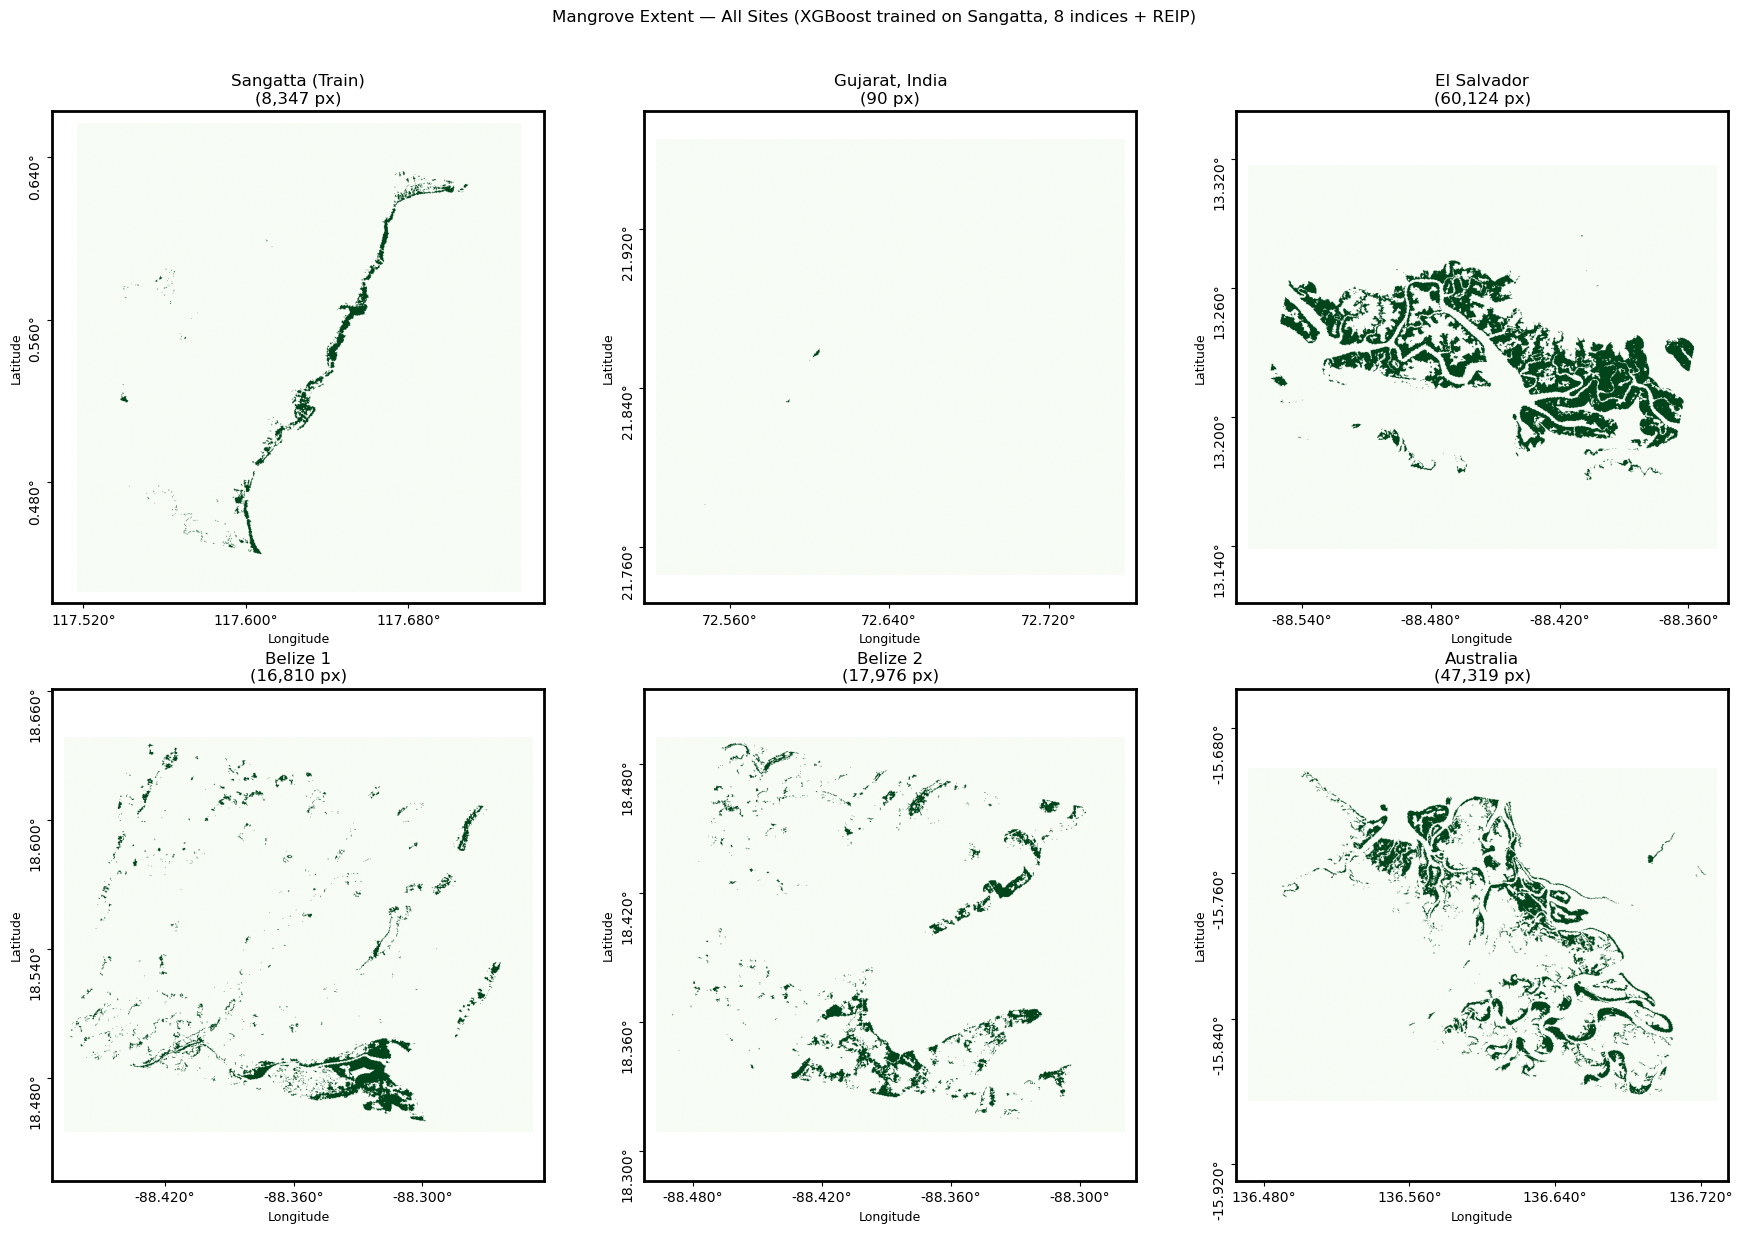

In [7]:
# ============================================================
# Load extent maps — 2x3 grid, square panel per site
# ============================================================
ALL_SITES = [('sangatta', '20250302_030003_92_4001')] + list(TRANSFER_SITES.items())
ALL_LABELS = {'sangatta': 'Sangatta (Train)'}
ALL_LABELS.update(SITE_LABELS)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (site, scene_id) in zip(axes, ALL_SITES):
    extent_path = DATA_PROC / f'extent_mangrove_{site}_{scene_id}.tif'
    if not extent_path.exists():
        ax.text(0.5, 0.5, f'{site}\nnot found',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue
    with rasterio.open(extent_path) as src:
        n_px = int((src.read(1) == 1).sum())
        _img, _ext = reproject_raster_to_4326(src)
    x0, x1, y0, y1 = _ext
    ax.imshow(_img == 1, extent=_ext, origin='upper', cmap='Greens')
    # Square extent: pad shorter axis to match longer, 5 % breathing room
    cx_ = (x0 + x1) / 2
    cy_ = (y0 + y1) / 2
    r   = max(x1 - x0, y1 - y0) / 2 * 1.05
    ax.set_xlim(cx_ - r, cx_ + r)
    ax.set_ylim(cy_ - r, cy_ + r)
    ax.set_aspect('equal')
    ax.set_title(f'{ALL_LABELS[site]}\n({n_px:,} px)')
    format_map_axes(ax, fontsize=9)

for j in range(len(ALL_SITES), len(axes)):
    axes[j].axis('off')

plt.suptitle('Mangrove Extent — All Sites (XGBoost trained on Sangatta, 8 indices + REIP)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_FIGURES / 'transferability_extent_maps.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Vector Export — Mangrove Extent Polygons

Polygonizes each `extent_mangrove_*.tif` raster to a GeoPackage (one file per site).
Each GPKG contains the dissolved mangrove polygon in the scene's native UTM CRS and is
used as the overlay layer in Section 6.

In [8]:
# ============================================================
# Polygonize extent rasters → GeoPackage (one file per site)
# Dissolves all mangrove polygons per scene into a single feature
# ============================================================
import rasterio.features
from shapely.geometry import shape
import geopandas as gpd

OUT_VECTOR = ROOT / 'outputs' / 'vector'
OUT_VECTOR.mkdir(parents=True, exist_ok=True)

ALL_SITES_VIZ = [('sangatta', '20250302_030003_92_4001')] + list(TRANSFER_SITES.items())
ALL_LABELS_VIZ = {'sangatta': 'Sangatta (Train)'}
ALL_LABELS_VIZ.update(SITE_LABELS)

for site, scene_id in ALL_SITES_VIZ:
    extent_path = DATA_PROC / f'extent_mangrove_{site}_{scene_id}.tif'
    if not extent_path.exists():
        print(f'  {site:<12}: raster not found — skip')
        continue

    with rasterio.open(extent_path) as src:
        img       = src.read(1)
        crs       = src.crs
        transform = src.transform

    mask  = (img == 1).astype('uint8')
    geoms = [
        shape(geom)
        for geom, val in rasterio.features.shapes(
            img.astype('uint8'), mask=mask, transform=transform
        )
        if val == 1
    ]
    if not geoms:
        print(f'  {site:<12}: no mangrove pixels — skip')
        continue

    gdf       = gpd.GeoDataFrame({'geometry': geoms}, crs=crs)
    gdf       = gdf.dissolve().reset_index(drop=True)
    gpkg_path = OUT_VECTOR / f'mangrove_extent_{site}_{scene_id}.gpkg'
    gdf.to_file(gpkg_path, driver='GPKG')

    area_ha = gdf.to_crs(gdf.estimate_utm_crs()).geometry.area.sum() / 1e4
    print(f'  {site:<12}: {len(gdf)} polygon(s)  {area_ha:,.1f} ha  -> {gpkg_path.name}')

print('\nVector export complete.')
print(f'Output directory : {OUT_VECTOR}')

  sangatta    : 1 polygon(s)  751.2 ha  -> mangrove_extent_sangatta_20250302_030003_92_4001.gpkg
  gujarat     : 1 polygon(s)  8.1 ha  -> mangrove_extent_gujarat_20250311_061550_53_4001.gpkg
  elsalvador  : 1 polygon(s)  5,411.2 ha  -> mangrove_extent_elsalvador_20250223_165546_32_4001.gpkg
  belize      : 1 polygon(s)  1,512.9 ha  -> mangrove_extent_belize_20250824_171853_67_4001.gpkg
  belize2     : 1 polygon(s)  1,617.8 ha  -> mangrove_extent_belize2_20250824_171857_84_4001.gpkg
  australia   : 1 polygon(s)  4,258.7 ha  -> mangrove_extent_australia_20250608_014315_58_4001.gpkg

Vector export complete.
Output directory : D:\OneDrive\PERSONAL PROJECT\2026\Planet Tanager Open Data Competition\tanager-mangrove-mapping\outputs\vector


## 6. Multi-Site Basemap Panel — True Color + Mangrove Extent

3-column × 2-row panel for all 6 sites (row 1: Sangatta, Gujarat, El Salvador;
row 2: Belize 1, Belize 2, Australia). Each panel shows:

- OpenStreetMap basemap (contextily)
- Tanager true-colour composite extracted from the raw HDF5 (R 660 nm, G 560 nm, B 480 nm)
  with 2–98 % percentile contrast stretch; only 3 bands are read from the 426-band cube
- Mangrove extent overlay: green fill (80 % opacity) and bold green stroke

[WARNING] System proj.db not found — basemap may fail
pyproj data dir (active)         : C:\Users\mwahy\miniconda3\envs\geoai\Library\share\proj
  [WARNING] basemap failed for sangatta: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mwahy\miniconda3\envs\geoai\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
  [WARNING] basemap failed for gujarat: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mwahy\miniconda3\envs\geoai\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
  [WARNING] basemap failed for elsalvador: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mwahy\miniconda3\envs\geoai\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
  [WA

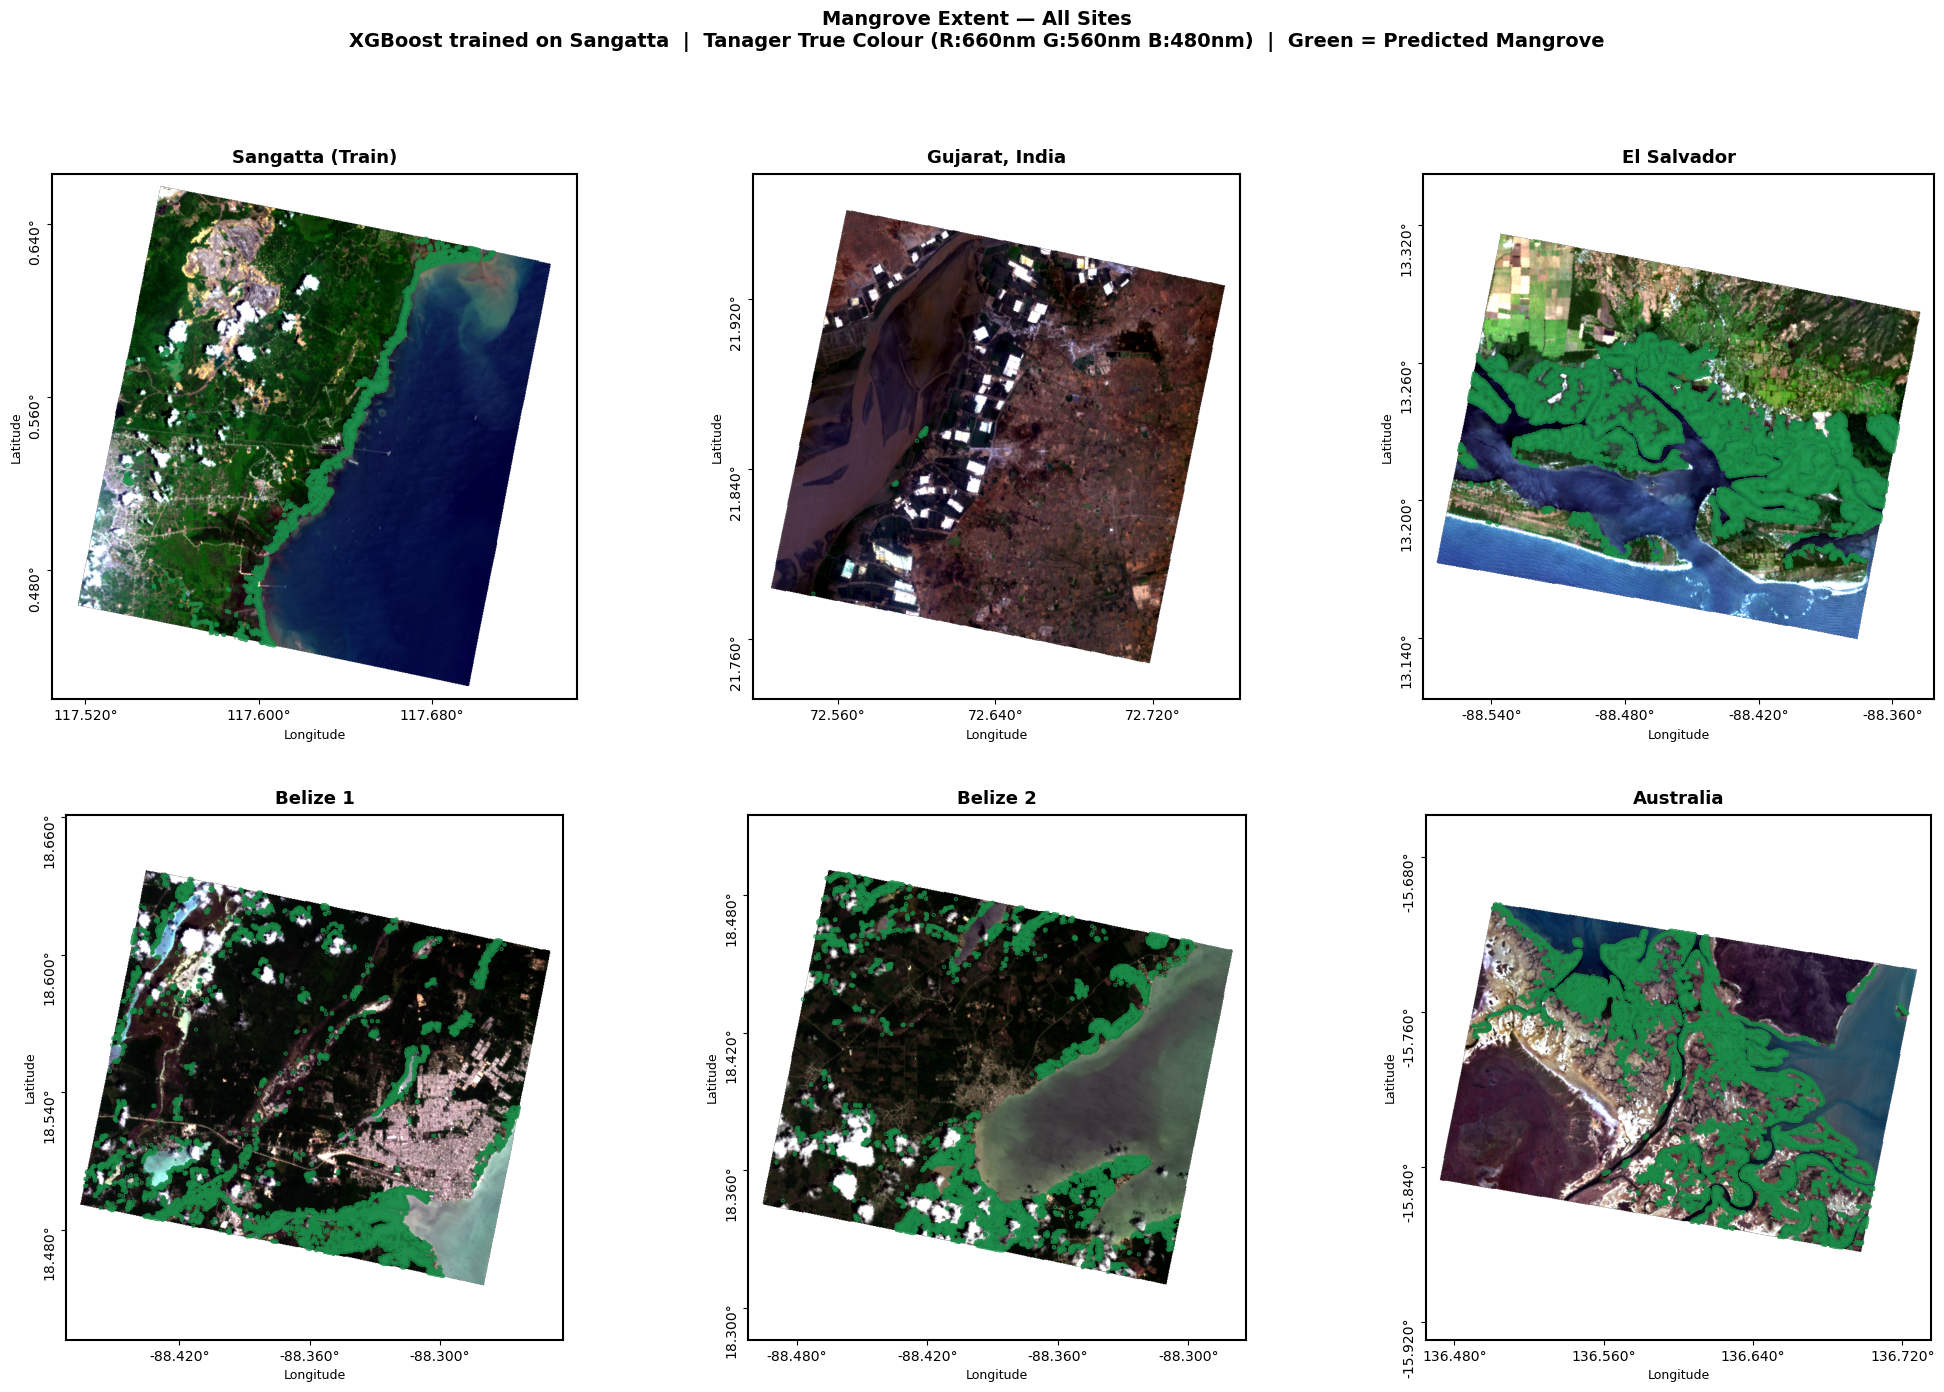

Saved : D:\OneDrive\PERSONAL PROJECT\2026\Planet Tanager Open Data Competition\tanager-mangrove-mapping\outputs\figures\transferability_basemap_panel.png


In [9]:
# !pip install contextily

# ============================================================
# Helpers
# ============================================================
import os
import re
import subprocess
import warnings
import h5py
import contextily as cx
from affine import Affine
from rasterio.crs import CRS as RasterioCRS
import pyproj

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------
# PROJ runtime fix for contextily on Colab
#
# Problem: pyproj on Colab links against the *system* PROJ (v6+),
# but our spatial_viz workaround sets PROJ_LIB to pyproj's bundled
# data dir which has a v4 proj.db — system PROJ 6+ rejects it.
# Setting os.environ after PROJ loads has no effect (cached at init).
#
# Fix: call pyproj.datadir.set_data_dir() which invokes the PROJ C
# API (proj_context_set_search_paths) and works at runtime.
# ---------------------------------------------------------------
def _find_system_proj_db():
    # Prefer the path reported by the system proj binary
    for cmd in [['proj', '--searchpath'], ['projinfo', '--searchpath']]:
        try:
            out = subprocess.check_output(cmd, stderr=subprocess.DEVNULL, text=True)
            for line in out.strip().splitlines():
                p = line.strip()
                if p and os.path.exists(os.path.join(p, 'proj.db')):
                    return p
        except Exception:
            pass
    # Common fallback locations on Debian/Ubuntu (Colab base OS)
    for p in ['/usr/share/proj', '/usr/local/share/proj']:
        if os.path.exists(os.path.join(p, 'proj.db')):
            return p
    return None

_system_proj = _find_system_proj_db()
if _system_proj:
    pyproj.datadir.set_data_dir(_system_proj)   # updates PROJ C context at runtime
    os.environ['PROJ_LIB']  = _system_proj
    os.environ['PROJ_DATA'] = _system_proj
    print(f'PROJ data dir set to system path : {_system_proj}')
else:
    print('[WARNING] System proj.db not found — basemap may fail')

print(f'pyproj data dir (active)         : {pyproj.datadir.get_data_dir()}')


def _load_rgb_hdf5(hdf5_path):
    """
    Read blue (480 nm), green (560 nm), red (660 nm) bands from a Tanager HDF5
    without loading the full 426-band cube.  Returns (red, green, blue, crs, transform).
    Nodata pixels (-9999) are replaced with NaN.
    """
    REFL = 'HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance'
    META = 'HDFEOS INFORMATION/StructMetadata.0'
    wl   = np.linspace(380, 2500, 426)
    b_i  = int(np.argmin(np.abs(wl - 480)))
    g_i  = int(np.argmin(np.abs(wl - 560)))
    r_i  = int(np.argmin(np.abs(wl - 660)))

    with h5py.File(hdf5_path, 'r') as f:
        ref   = f[REFL]
        blue  = ref[b_i].astype(np.float32)
        green = ref[g_i].astype(np.float32)
        red   = ref[r_i].astype(np.float32)
        epsg  = int(f['HDFEOS/GRIDS/HYP'].attrs['epsg_code'])
        meta  = f[META][()].decode()

    for band in (blue, green, red):
        band[band <= -9999.0] = np.nan

    ul   = re.search(r'UpperLeftPointMtrs=\(([0-9.\-]+),([0-9.\-]+)\)', meta)
    lr   = re.search(r'LowerRightMtrs=\(([0-9.\-]+),([0-9.\-]+)\)', meta)
    xdim = re.search(r'XDim=(\d+)', meta)
    ul_x, ul_y = float(ul.group(1)), float(ul.group(2))
    pixel      = (float(lr.group(1)) - ul_x) / int(xdim.group(1))
    transform  = Affine(pixel, 0, ul_x, 0, -pixel, ul_y)
    crs        = RasterioCRS.from_wkt(pyproj.CRS.from_epsg(epsg).to_wkt())

    return red, green, blue, crs, transform


def _make_rgba(red, green, blue):
    """Apply 2-98 % contrast stretch; return an (H, W, 4) RGBA float32 array."""
    stacked = np.stack([red, green, blue], axis=-1)
    valid   = ~np.any(np.isnan(stacked), axis=-1)
    rgba    = np.zeros((*stacked.shape[:2], 4), dtype=np.float32)
    for i, band in enumerate([red, green, blue]):
        if np.any(valid):
            vp      = band[valid]
            p2, p98 = np.percentile(vp, [2, 98])
            norm    = (np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1)
                       if p98 > p2 else np.clip(band, 0, 1))
        else:
            norm = np.clip(band, 0, 1)
        rgba[:, :, i] = np.where(np.isnan(norm), 0.0, norm) * valid
    rgba[:, :, 3] = valid.astype(np.float32)
    return rgba


# ============================================================
# Layout: 3 columns x 2 rows — all 6 sites
# ============================================================
ALL_SITES_VIZ  = [('sangatta', '20250302_030003_92_4001')] + list(TRANSFER_SITES.items())
ALL_LABELS_VIZ = {'sangatta': 'Sangatta (Train)'}
ALL_LABELS_VIZ.update(SITE_LABELS)

OUT_VECTOR = ROOT / 'outputs' / 'vector'

MANGROVE_FILL   = '#27AE60'
MANGROVE_STROKE = '#1A8A47'
FILL_ALPHA      = 0.80
STROKE_WIDTH    = 2.5

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes = axes.flatten()

for ax, (site, scene_id) in zip(axes, ALL_SITES_VIZ):
    label     = ALL_LABELS_VIZ.get(site, site)
    hdf5_path = DATA_RAW / f'{site}_{scene_id}_ortho_sr_hdf5.h5'

    if not hdf5_path.exists():
        ax.text(0.5, 0.5, f'{label}\nHDF5 not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.axis('off')
        continue

    # -- True colour from HDF5 (3 bands only) --------------------------
    red, green_b, blue, hdf5_crs, hdf5_tf = _load_rgb_hdf5(str(hdf5_path))
    rgba                                    = _make_rgba(red, green_b, blue)

    _, extent = reproject_array_to_4326(red, hdf5_crs, hdf5_tf)
    reproj_channels = []
    for ch in range(4):
        ch_repr, _ = reproject_array_to_4326(rgba[:, :, ch], hdf5_crs, hdf5_tf)
        reproj_channels.append(ch_repr)
    rgba_repr = np.clip(np.stack(reproj_channels, axis=-1), 0, 1)

    # -- Square extent centered on scene, 5 % breathing room -----------
    x0, x1, y0, y1 = extent
    cx_ = (x0 + x1) / 2
    cy_ = (y0 + y1) / 2
    r   = max(x1 - x0, y1 - y0) / 2 * 1.05
    ax.set_xlim(cx_ - r, cx_ + r)
    ax.set_ylim(cy_ - r, cy_ + r)
    ax.set_aspect('equal')

    # -- Layer 1: OSM basemap ------------------------------------------
    try:
        cx.add_basemap(ax, crs='EPSG:4326',
                       source=cx.providers.OpenStreetMap.Mapnik,
                       zorder=1, alpha=1.0)
    except Exception as e:
        print(f'  [WARNING] basemap failed for {site}: {e}')

    # -- Layer 2: Tanager true colour ----------------------------------
    ax.imshow(rgba_repr, extent=extent, origin='upper', zorder=2)

    # -- Layer 3: Mangrove extent polygon ------------------------------
    gpkg_path = OUT_VECTOR / f'mangrove_extent_{site}_{scene_id}.gpkg'
    if gpkg_path.exists():
        gdf_gcs = gpd.read_file(gpkg_path).to_crs('EPSG:4326')
        gdf_gcs.plot(ax=ax,
                     facecolor=MANGROVE_FILL,
                     edgecolor=MANGROVE_STROKE,
                     alpha=FILL_ALPHA,
                     linewidth=STROKE_WIDTH,
                     zorder=3)
    else:
        print(f'  [WARNING] GPKG not found for {site} — run Section 5 first')

    ax.set_title(label, fontsize=13, fontweight='bold', pad=8)
    format_map_axes(ax, fontsize=9, spine_color='black', spine_width=1.5)

fig.suptitle(
    'Mangrove Extent — All Sites\n'
    'XGBoost trained on Sangatta  |  '
    'Tanager True Colour (R:660nm G:560nm B:480nm)  |  '
    'Green = Predicted Mangrove',
    fontsize=14, fontweight='bold', y=1.01,
)
fig.tight_layout(pad=3.0, h_pad=3.5, w_pad=3.0)

out_png = OUT_FIGURES / 'transferability_basemap_panel.png'
plt.savefig(out_png, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved : {out_png}')